# NSSC 2026 Mars HiRISE Anomaly Detection

This notebook records our from-scratch autoencoder experiments, latent Isolation Forest scoring, distribution-based thresholding, robustness testing, and reconstruction hypotheses. 
We strictly follow competition constraints: no pretrained visual encoders, fixed-length latent vectors, and unbiased statistical thresholding without tuning contamination to force a target count.


In [1]:
from pathlib import Path
import os, sys, json, importlib.util, subprocess
if Path('/kaggle/working').exists(): ROOT=Path('/kaggle/working/mars_project')
elif Path('/content').exists(): ROOT=Path('/content/mars_project')
else:
    ROOT=Path.cwd()
    if ROOT.name=='notebooks':ROOT=ROOT.parent
ROOT.mkdir(parents=True,exist_ok=True);os.chdir(ROOT);sys.path.insert(0,str(ROOT))
required={'numpy':'numpy','pandas':'pandas','PIL':'Pillow','scipy':'scipy','sklearn':'scikit-learn','matplotlib':'matplotlib','statsmodels':'statsmodels','torch':'torch'}
missing=[v for k,v in required.items() if importlib.util.find_spec(k) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
import torch,numpy as np,pandas as pd,matplotlib.pyplot as plt
from IPython.display import display,Image,Markdown
print('Project:',ROOT,'| PyTorch:',torch.__version__,'| CUDA available:',torch.cuda.is_available())


Project: C:\Users\deves\OneDrive\Desktop\Projects\IIT_KGP_DA_PS | PyTorch: 2.7.1+cu128 | CUDA available: True


In [2]:
EMBEDDED_FILES = {'mars_anomaly/data.py': 'from pathlib import Path\nimport io\nfrom zipfile import ZipFile\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom PIL import Image\nfrom torch.utils.data import Dataset\nfrom .preprocessing import preprocess_array,MODES\n\n\ndef prepare_archive(archive, destination):\n    """Extract only the known dataset structure, never arbitrary archive paths."""\n    destination = Path(destination)\n    destination.mkdir(parents=True, exist_ok=True)\n    with ZipFile(archive) as outer:\n        for name in (\'crop_metadata_index.csv\', \'source_image_metadata.csv\'):\n            (destination / name).write_bytes(outer.read(\'DATASETS/\' + name))\n        payload = outer.read(\'DATASETS/images.zip\')\n    expected = set(pd.read_csv(destination / \'crop_metadata_index.csv\').filename)\n    seen = set()\n    image_dir = destination / \'images\'\n    image_dir.mkdir(exist_ok=True)\n    with ZipFile(io.BytesIO(payload)) as inner:\n        for entry in inner.infolist():\n            if entry.is_dir():\n                continue\n            name = Path(entry.filename).name\n            if name not in expected or name in seen:\n                raise ValueError(f\'Unexpected or duplicate image: {name}\')\n            seen.add(name)\n            target = image_dir / name\n            if not target.exists():\n                target.write_bytes(inner.read(entry))\n    if seen != expected:\n        raise ValueError(\'Archive and crop index do not match\')\n    return destination\n\n\ndef load_manifest(data_dir, seed=2026):\n    data_dir = Path(data_dir)\n    crops = pd.read_csv(data_dir / \'crop_metadata_index.csv\')\n    sources = pd.read_csv(data_dir / \'source_image_metadata.csv\')\n    if not crops.filename.is_unique or not sources.source_image_id.is_unique:\n        raise ValueError(\'Duplicate metadata join keys\')\n    frame = crops.merge(sources, on=\'source_image_id\', how=\'left\', validate=\'many_to_one\')\n    if frame.isna().any().any():\n        raise ValueError(\'Missing metadata\')\n    groups = np.array(sorted(frame.source_image_id.unique()))\n    if len(groups) < 10:\n        raise ValueError(\'At least 10 source groups required\')\n    np.random.default_rng(seed).shuffle(groups)\n    n_train, n_val = int(.7 * len(groups)), int(.15 * len(groups))\n    assignment = {g: (\'train\' if i < n_train else \'validation\' if i < n_train+n_val else \'calibration\') for i,g in enumerate(groups)}\n    frame[\'split\'] = frame.source_image_id.map(assignment)\n    frame[\'path\'] = [str(data_dir / \'images\' / name) for name in frame.filename]\n    if not all(Path(p).is_file() for p in frame.path):\n        raise FileNotFoundError(\'Some indexed image files are missing\')\n    return frame\n\n\nclass CropDataset(Dataset):\n    def __init__(self, frame, preprocessing=\'raw\'):\n        self.frame = frame.reset_index(drop=True)\n        if preprocessing not in MODES:raise ValueError(\'Unknown preprocessing mode\')\n        self.preprocessing=preprocessing\n\n    def __len__(self):\n        return len(self.frame)\n\n    def __getitem__(self, index):\n        row = self.frame.iloc[index]\n        with Image.open(row.path) as image:\n            if image.mode != \'L\' or image.size != (227,227):\n                raise ValueError(f\'Unexpected image contract: {row.filename}\')\n            array = np.array(image, dtype=np.float32) / 255.\n        return torch.from_numpy(preprocess_array(array,self.preprocessing)).unsqueeze(0), index\n', 'mars_anomaly/evaluate.py': "import argparse\nimport json\nfrom pathlib import Path\nimport joblib\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\nfrom sklearn.ensemble import IsolationForest\nfrom sklearn.decomposition import PCA\nfrom sklearn.manifold import TSNE\nfrom scipy.stats import spearmanr\nfrom .data import load_manifest,CropDataset\nfrom .model import ConvAutoencoder\nfrom .threshold import calibrate,select_flagged\nfrom .visualize import score_plots,heatmap_panel\n\n\ndef evaluate(data_dir,run_dir,bootstrap=100,projection=True,allow_smoke=False,method='adjusted_boxplot',trees=400):\n    run_dir = Path(run_dir)\n    checkpoint = torch.load(run_dir/'best.pt',map_location='cpu',weights_only=False)\n    config = checkpoint['config']\n    if method!='adjusted_boxplot' or trees!=400:\n        run_dir=run_dir/(method+(f'_trees{trees}' if trees!=400 else ''))\n        run_dir.mkdir(parents=True,exist_ok=True)\n    if config['max_batches'] and not allow_smoke:\n        raise ValueError('Smoke checkpoint cannot produce competition results')\n    torch.set_num_threads(4)\n    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')\n    model = ConvAutoencoder(config['latent_dim']).to(device)\n    model.load_state_dict(checkpoint['model']);model.eval()\n    frame = load_manifest(data_dir,config.get('split_seed',config['seed']))\n    preprocessing=config.get('preprocessing','raw')\n    loader = DataLoader(CropDataset(frame,preprocessing),batch_size=config['batch_size'],num_workers=0)\n    latents,errors = [],[]\n    with torch.no_grad():\n        for x,_ in loader:\n            x = x.to(device)\n            reconstruction,z = model(x)\n            latents.append(z.cpu().numpy())\n            errors.extend((x-reconstruction).square().mean((1,2,3)).cpu().tolist())\n    z = np.concatenate(latents)\n    np.save(run_dir/'latents.npy',z)\n    np.save(run_dir/'latent_filenames.npy',frame.filename.to_numpy(dtype=str))\n    train = frame.split.eq('train').to_numpy()\n    calibration_mask = frame.split.eq('calibration').to_numpy()\n    forest = IsolationForest(n_estimators=trees,max_samples=256,contamination='auto',random_state=config['seed'],n_jobs=2)\n    forest.fit(z[train])\n    frame['novelty_score'] = -forest.score_samples(z)\n    frame['reconstruction_mse'] = errors\n    calibration = calibrate(frame.loc[calibration_mask,'novelty_score'],frame.loc[calibration_mask,'source_image_id'],bootstrap,config['seed'],method)\n    frame['flagged'] = frame.novelty_score>calibration['threshold']\n    boot = np.asarray(calibration['bootstrap_thresholds'])\n    frame['threshold_bootstrap_flag_frequency'] = (frame.novelty_score.to_numpy()[:,None]>boot[None,:]).mean(1)\n    # Independent forests assess Monte Carlo rank variability, not hidden-label accuracy.\n    stability = []\n    for seed in (config['seed']+1,config['seed']+2):\n        other = IsolationForest(n_estimators=trees,max_samples=256,contamination='auto',random_state=seed,n_jobs=2).fit(z[train])\n        other_scores = -other.score_samples(z)\n        from .threshold import upper_fence,mixture_fence\n        boundary = (upper_fence(other_scores[calibration_mask]) if method=='adjusted_boxplot' else mixture_fence(other_scores[calibration_mask],config['seed']))['threshold']\n        other_flags = other_scores>boundary\n        primary_flags = frame.flagged.to_numpy()\n        union = np.count_nonzero(primary_flags|other_flags)\n        stability.append({'seed':seed,'spearman':float(spearmanr(frame.novelty_score,other_scores).statistic),'flag_count':int(other_flags.sum()),'threshold':boundary,'flag_jaccard':float(np.count_nonzero(primary_flags&other_flags)/union) if union else None})\n    covariance = np.cov(z[train],rowvar=False)\n    eigenvalues = np.linalg.eigvalsh(covariance).clip(0)\n    proportions = eigenvalues/max(eigenvalues.sum(),1e-12)\n    effective_rank = float(np.exp(-np.sum(proportions*np.log(proportions+1e-12))))\n    diagnostics = {'effective_rank':effective_rank,'latent_dimensions':z.shape[1],'latent_variance':z[train].var(0).tolist(),'forest_seed_stability':stability,'flagged_total':int(frame.flagged.sum()),'flagged_by_split':frame.groupby('split').flagged.agg(['sum','count','mean']).to_dict(),'smoke_checkpoint':bool(config['max_batches']),'threshold_exceeds_maximum':bool(calibration['threshold']>frame.novelty_score.max())}\n    diagnostics['n_estimators']=trees\n    diagnostics['preprocessing']=preprocessing\n    diagnostics['reconstruction_domain']='raw intensity / 255' if preprocessing=='raw' else preprocessing+' standardized input'\n    if method=='mixture_three_sigma':\n        from scipy.stats import norm\n        means=np.array(calibration['means']);std=np.array(calibration['std']);weights=np.array(calibration['weights'])\n        heldout=np.sort(frame.loc[frame.split.eq('validation'),'novelty_score'])\n        cdf=np.sum(weights*norm.cdf((heldout[:,None]-means)/std),axis=1)\n        n=len(heldout)\n        diagnostics['validation_cdf_max_distance']=float(max(np.max(np.arange(1,n+1)/n-cdf),np.max(cdf-np.arange(n)/n)))\n        diagnostics['validation_cdf_note']='Descriptive held-out density-fit diagnostic; correlated sources preclude an ordinary IID KS p-value.'\n    (run_dir/'calibration.json').write_text(json.dumps(calibration,indent=2))\n    (run_dir/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2))\n    frame.drop(columns='path').to_csv(run_dir/'novelty_scores.csv',index=False)\n    joblib.dump(forest,run_dir/'isolation_forest.joblib')\n    score_plots(frame,calibration,run_dir/'score_distribution.png')\n    source_summary = frame.groupby('source_image_id').agg(crops=('filename','size'),flagged=('flagged','sum'),mean_novelty=('novelty_score','mean'),latitude=('latitude','first'),longitude=('longitude','first'),sun_angle=('sun_angle','first'),season=('season','first'),resolution=('resolution','first'))\n    source_summary['flag_rate'] = source_summary.flagged/source_summary.crops\n    source_summary.to_csv(run_dir/'source_summary.csv')\n    for column in ('season','resolution','longitude'):\n        crop_summary = frame.groupby(column).flagged.agg(['count','sum','mean'])\n        equal_source = source_summary.groupby(column).flag_rate.mean()\n        crop_summary['equal_source_mean_flag_rate'] = equal_source\n        crop_summary.to_csv(run_dir/f'metadata_{column}.csv')\n    selected = select_flagged(frame,calibration['threshold'])\n    selected.drop(columns='path').to_csv(run_dir/'selected_for_interpretation.csv',index=False)\n    for _,row in selected.iterrows():\n        x,_ = CropDataset(pd.DataFrame([row]),preprocessing)[0]\n        with torch.no_grad(): rec = model(x[None].to(device))[0][0,0].cpu().numpy()\n        if preprocessing=='raw':\n            heatmap_panel(x[0].numpy(),rec,row,calibration['threshold'],run_dir/f'heatmap_{Path(row.filename).stem}.png')\n        else:\n            from .visualize import standardized_heatmap_panel\n            raw,_=CropDataset(pd.DataFrame([row]))[0]\n            standardized_heatmap_panel(raw[0].numpy(),x[0].numpy(),rec,row,calibration['threshold'],run_dir/f'heatmap_{Path(row.filename).stem}.png',preprocessing)\n    if projection:\n        import matplotlib.pyplot as plt\n        # Standardization affects visualization only; the forest uses the original latent.\n        scale = z[train].std(0).clip(1e-6)\n        standardized = (z-z[train].mean(0))/scale\n        reduced = PCA(n_components=min(50,z.shape[1]),random_state=config['seed']).fit_transform(standardized)\n        for perplexity in (30,70):\n            xy = TSNE(n_components=2,perplexity=perplexity,init='pca',learning_rate='auto',random_state=config['seed'],max_iter=1000).fit_transform(reduced)\n            pd.DataFrame({'filename':frame.filename,'x':xy[:,0],'y':xy[:,1]}).to_csv(run_dir/f'tsne_{perplexity}.csv',index=False)\n            fig,axes = plt.subplots(1,3,figsize=(15,4))\n            for ax,values,title in zip(axes,[frame.novelty_score,frame.sun_angle,pd.Categorical(frame.source_image_id).codes],['Novelty score','Sun angle as supplied','Source ID (categorical colors)']):\n                points = ax.scatter(xy[:,0],xy[:,1],c=values,s=3,cmap='viridis',rasterized=True)\n                fig.colorbar(points,ax=ax);ax.set_title(title);ax.set_xticks([]);ax.set_yticks([])\n            fig.suptitle(f't-SNE perplexity {perplexity}; qualitative projection, not geological labels')\n            fig.tight_layout();fig.savefig(run_dir/f'tsne_{perplexity}.png',dpi=160);plt.close(fig)\n    print(json.dumps({k:v for k,v in diagnostics.items() if k!='latent_variance'},indent=2),flush=True)\n    return frame,calibration,diagnostics\n\n\ndef main():\n    parser=argparse.ArgumentParser()\n    parser.add_argument('--data',default='data');parser.add_argument('--run',required=True)\n    parser.add_argument('--bootstrap',type=int,default=100);parser.add_argument('--no-projection',action='store_true')\n    parser.add_argument('--method',choices=['adjusted_boxplot','mixture_three_sigma'],default='adjusted_boxplot')\n    parser.add_argument('--trees',type=int,default=400)\n    args=parser.parse_args()\n    evaluate(args.data,args.run,args.bootstrap,not args.no_projection,method=args.method,trees=args.trees)\n\nif __name__=='__main__': main()\n", 'mars_anomaly/model.py': 'import torch\nfrom torch import nn\nfrom torch.nn import functional as F\n\n\nclass ConvAutoencoder(nn.Module):\n    """No pretrained weights, external features, or bottleneck bypass."""\n    def __init__(self, latent_dim=128):\n        super().__init__()\n        channels = (1,16,32,64,96,128)\n        blocks = []\n        for cin,cout in zip(channels[:-1],channels[1:]):\n            blocks.extend([nn.Conv2d(cin,cout,3,stride=2,padding=1), nn.GroupNorm(8,cout), nn.SiLU()])\n        self.encoder = nn.Sequential(*blocks)\n        self.to_latent = nn.Linear(128*8*8, latent_dim)\n        self.from_latent = nn.Linear(latent_dim,128*8*8)\n        self.decoder = nn.ModuleList()\n        for cin,cout in zip((128,96,64,32,16),(96,64,32,16,1)):\n            layers = [nn.Conv2d(cin,cout,3,padding=1)]\n            layers += [nn.Sigmoid()] if cout == 1 else [nn.GroupNorm(8,cout),nn.SiLU()]\n            self.decoder.append(nn.Sequential(*layers))\n\n    def encode(self,x):\n        return self.to_latent(self.encoder(x).flatten(1))\n\n    def decode(self,z):\n        x = self.from_latent(z).reshape(-1,128,8,8)\n        for size,block in zip((15,29,57,114,227),self.decoder):\n            x = block(F.interpolate(x,size=(size,size),mode=\'bilinear\',align_corners=False))\n        return x\n\n    def forward(self,x):\n        z = self.encode(x)\n        return self.decode(z),z\n\n\ndef ssim_per_image(x,y):\n    """11x11 Gaussian-window SSIM, sigma 1.5, data range 1, valid windows."""\n    x,y = x.float(),y.float()\n    coords = torch.arange(11,device=x.device,dtype=x.dtype)-5\n    weights = torch.exp(-coords.square()/(2*1.5**2))\n    weights = weights / weights.sum()\n    # Separable filters compute the same Gaussian window with less work.\n    def smooth(a):\n        a = F.conv2d(a,weights.reshape(1,1,1,11))\n        return F.conv2d(a,weights.reshape(1,1,11,1))\n    mx,my = smooth(x),smooth(y)\n    vx = (smooth(x*x)-mx*mx).clamp_min(0)\n    vy = (smooth(y*y)-my*my).clamp_min(0)\n    cov = smooth(x*y)-mx*my\n    result = ((2*mx*my+.01**2)*(2*cov+.03**2))/((mx*mx+my*my+.01**2)*(vx+vy+.03**2))\n    return result.mean((1,2,3))\n\n\ndef loss_components(x,reconstruction,structural_weight=0.,gradient_weight=0.):\n    x,reconstruction = x.float(),reconstruction.float()\n    mse = (x-reconstruction).square().mean((1,2,3))\n    with torch.set_grad_enabled(torch.is_grad_enabled() and structural_weight>0):\n        ssim = ssim_per_image(x,reconstruction)\n    dx = (x[:,:,:,1:]-x[:,:,:,:-1])-(reconstruction[:,:,:,1:]-reconstruction[:,:,:,:-1])\n    dy = (x[:,:,1:,:]-x[:,:,:-1,:])-(reconstruction[:,:,1:,:]-reconstruction[:,:,:-1,:])\n    gradient = .5*(dx.abs().mean((1,2,3))+dy.abs().mean((1,2,3)))\n    loss = (1-structural_weight)*mse\n    if structural_weight: loss = loss+structural_weight*(1-ssim)\n    if gradient_weight: loss = loss+gradient_weight*gradient\n    return {\'loss\':loss.mean(),\'mse\':mse.mean(),\'ssim\':ssim.mean(),\'gradient\':gradient.mean()}\n', 'mars_anomaly/preprocessing.py': '"""Explicit, per-image photometric ablations; no fitted dataset statistics."""\nimport numpy as np\nfrom scipy.ndimage import label, binary_dilation, distance_transform_edt\n\nMODES=(\'raw\',\'contrast\',\'footprint\',\'border_fill\')\n\n\ndef border_zero_mask(array):\n    regions,_=label(array==0)\n    border=np.unique(np.concatenate([regions[0],regions[-1],regions[:,0],regions[:,-1]]))\n    return np.isin(regions,border[border!=0])\n\n\ndef border_near_black_mask(array):\n    """Fixed JPEG-tolerant border heuristic; not a ground-truth validity mask."""\n    regions, _ = label(array <= 4/255)\n    edge = np.unique(np.concatenate([regions[0],regions[-1],regions[:,0],regions[:,-1]]))\n    mask = np.isin(regions, edge[edge != 0])\n    return binary_dilation(mask, iterations=2) if mask.any() else mask\n\n\ndef preprocess_array(array,mode=\'raw\'):\n    if mode not in MODES:raise ValueError(f\'Unknown preprocessing: {mode}\')\n    x=np.asarray(array,dtype=np.float32)\n    if x.ndim!=2 or not np.isfinite(x).all():raise ValueError(\'Expected finite 2D image\')\n    if mode==\'raw\':return x\n    excluded=(border_near_black_mask(x) if mode==\'border_fill\' else\n              border_zero_mask(x) if mode==\'footprint\' else np.zeros(x.shape,dtype=bool))\n    values=x[~excluded]\n    if not len(values):return np.full_like(x,.5)\n    mean=float(values.mean());std=max(float(values.std()),1/255)\n    result=np.clip(.5+.15*(x-mean)/std,0,1).astype(np.float32)\n    if mode==\'border_fill\' and excluded.any():\n        nearest=distance_transform_edt(excluded,return_distances=False,return_indices=True)\n        result[excluded]=result[tuple(nearest[:,excluded])]\n    else:\n        result[excluded]=.5\n    return result\n', 'mars_anomaly/threshold.py': 'import numpy as np\nfrom statsmodels.stats.stattools import medcouple\n\n\ndef mixture_fence(scores,seed=2026):\n    """Envelope beyond every fitted score population; no contamination fraction."""\n    from sklearn.mixture import GaussianMixture\n    from threadpoolctl import threadpool_limits\n    from scipy.stats import norm\n    values=np.asarray(scores,dtype=float)\n    if values.ndim!=1 or len(values)<30 or not np.isfinite(values).all() or values.std()<1e-8:\n        raise ValueError(\'Need at least 30 finite, nonconstant scores for a mixture\')\n    with threadpool_limits(limits=2):\n        models=[GaussianMixture(n_components=k,n_init=5,random_state=seed,reg_covar=1e-6).fit(values[:,None]) for k in range(1,5)]\n    valid=[m for m in models if m.converged_]\n    if not valid: raise ValueError(\'No mixture fit converged\')\n    best=min(valid,key=lambda m:m.bic(values[:,None]))\n    means=best.means_.ravel();sigmas=np.sqrt(best.covariances_.ravel())\n    threshold=float(np.max(means+3*sigmas))\n    ordered=np.sort(values)\n    cdf=np.sum(best.weights_[None,:]*norm.cdf((ordered[:,None]-means)/sigmas),axis=1)\n    n=len(values)\n    ks=float(max(np.max(np.arange(1,n+1)/n-cdf),np.max(cdf-np.arange(n)/n)))\n    return {\'threshold\':threshold,\'method\':\'mixture_three_sigma\',\'components\':best.n_components,\'bic\':{str(m.n_components):float(m.bic(values[:,None])) for m in valid},\'weights\':best.weights_.tolist(),\'means\':means.tolist(),\'std\':sigmas.tolist(),\'calibration_cdf_max_distance\':ks,\'fitted_tail_mass\':float(np.sum(best.weights_*norm.sf((threshold-means)/sigmas))),\'component_count_at_search_limit\':best.n_components==4}\n\n\ndef upper_fence(scores):\n    values = np.asarray(scores,dtype=float)\n    if values.ndim != 1 or len(values)<8 or not np.isfinite(values).all():\n        raise ValueError(\'Need at least 8 finite calibration scores\')\n    q1,q3 = np.quantile(values,[.25,.75])\n    iqr = q3-q1\n    if iqr <= np.finfo(float).eps:\n        raise ValueError(\'Degenerate calibration IQR; investigate representation and scores\')\n    mc = float(medcouple(values))\n    multiplier = 3 if mc>=0 else 4\n    fence = q3 + 1.5*np.exp(multiplier*mc)*iqr\n    return {\'threshold\':float(fence),\'q1\':float(q1),\'q3\':float(q3),\'iqr\':float(iqr),\'medcouple\':mc}\n\n\ndef calibrate(scores,groups,bootstrap=100,seed=2026,method=\'adjusted_boxplot\'):\n    values,groups = np.asarray(scores),np.asarray(groups)\n    if values.shape != groups.shape:\n        raise ValueError(\'Scores and groups must have equal shape\')\n    unique = np.unique(groups)\n    if len(unique)<8:\n        raise ValueError(\'Too few calibration source groups for bootstrap\')\n    if method not in (\'adjusted_boxplot\',\'mixture_three_sigma\'): raise ValueError(\'Unknown threshold method\')\n    boundary = upper_fence if method==\'adjusted_boxplot\' else lambda x:mixture_fence(x,seed)\n    result = boundary(values)\n    result[\'method\']=method\n    rng = np.random.default_rng(seed)\n    indices = [np.flatnonzero(groups==g) for g in unique]\n    thresholds = []\n    for _ in range(bootstrap):\n        sample = np.concatenate([indices[i] for i in rng.integers(0,len(unique),len(unique))])\n        try:\n            thresholds.append(boundary(values[sample])[\'threshold\'])\n        except ValueError:\n            continue\n    if len(thresholds)<max(10,bootstrap*.8):\n        raise ValueError(\'Too many degenerate bootstrap replicates\')\n    median = np.median(values)\n    mad = np.median(np.abs(values-median))\n    q1,q3=np.quantile(values,[.25,.75])\n    result.update({\'bootstrap_interval_95\':np.quantile(thresholds,[.025,.975]).tolist(), \'bootstrap_thresholds\':thresholds,\'bootstrap_valid\':len(thresholds),\'calibration_images\':len(values),\'calibration_sources\':len(unique),\'tukey_comparison\':float(q3+1.5*(q3-q1)),\'mad_comparison\':float(median+3*1.4826*mad),\'interpretation\':\'Descriptive distribution-based screening boundary; no nominal false-positive or false-discovery guarantee.\'})\n    return result\n\n\ndef select_flagged(frame,threshold,limit=5):\n    """The limit is only for explanations, never for threshold determination."""\n    return frame.loc[frame.novelty_score>threshold].sort_values([\'novelty_score\',\'filename\'],ascending=[False,True]).head(limit)\n', 'mars_anomaly/train.py': 'import argparse\nfrom dataclasses import asdict,dataclass\nfrom pathlib import Path\nimport json\nimport random\nimport time\nimport platform\nfrom datetime import datetime\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom torch.utils.data import DataLoader\nfrom .data import CropDataset,load_manifest\nfrom .model import ConvAutoencoder,loss_components\n\n\n@dataclass\nclass TrainConfig:\n    version: str = \'v1\'\n    latent_dim: int = 128\n    epochs: int = 15\n    batch_size: int = 16\n    learning_rate: float = .0003\n    structural_weight: float = 0.\n    gradient_weight: float = 0.\n    seed: int = 2026\n    split_seed: int = 2026\n    preprocessing: str = \'raw\'\n    workers: int = 0\n    patience: int = 5\n    max_batches: int = 0\n    augment: bool = False\n\n\ndef atomic_checkpoint(state, destination):\n    """Keep the previous checkpoint intact if serialization fails partway."""\n    destination = Path(destination)\n    temporary = destination.with_suffix(\'.tmp.pt\')\n    torch.save(state, temporary)\n    temporary.replace(destination)\n\n\ndef run_training(data_dir,output_dir,config, resume=False):\n    if config.epochs<1 or not 0<=config.structural_weight<=1 or config.gradient_weight<0:\n        raise ValueError(\'Invalid training configuration\')\n    output_dir = Path(output_dir)\n    output_dir.mkdir(parents=True,exist_ok=True)\n    last = output_dir/\'last.pt\'\n    if last.exists() and not resume:\n        raise FileExistsError(f\'{last} already exists; choose a new run directory or resume\')\n    random.seed(config.seed);np.random.seed(config.seed);torch.manual_seed(config.seed)\n    if torch.cuda.is_available(): torch.cuda.manual_seed_all(config.seed)\n    torch.set_num_threads(4)\n    torch.backends.cudnn.benchmark = False\n    torch.backends.cudnn.deterministic = True\n    device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n    manifest = load_manifest(data_dir,config.split_seed)\n    loaders = {split:DataLoader(CropDataset(manifest[manifest.split==split],config.preprocessing),batch_size=config.batch_size,shuffle=split==\'train\',num_workers=config.workers,pin_memory=device.type==\'cuda\') for split in [\'train\',\'validation\']}\n    model = ConvAutoencoder(config.latent_dim).to(device)\n    optimizer = torch.optim.AdamW(model.parameters(),lr=config.learning_rate,weight_decay=.0001)\n    scaler = torch.amp.GradScaler(\'cuda\',enabled=device.type==\'cuda\')\n    start,best,stale,history = 0,float(\'inf\'),0,[]\n    if resume:\n        checkpoint = torch.load(last,map_location=device,weights_only=False)\n        prior = checkpoint[\'config\']\n        if prior.get(\'preprocessing\',\'raw\')!=config.preprocessing:raise ValueError(\'Resume mismatch: preprocessing\')\n        if prior.get(\'split_seed\',prior[\'seed\']) != config.split_seed:\n            raise ValueError(\'Resume mismatch: split_seed\')\n        for key in [\'latent_dim\',\'structural_weight\',\'gradient_weight\',\'seed\',\'batch_size\',\'learning_rate\',\'max_batches\',\'augment\']:\n            if prior[key] != asdict(config)[key]: raise ValueError(f\'Resume mismatch: {key}\')\n        model.load_state_dict(checkpoint[\'model\']);optimizer.load_state_dict(checkpoint[\'optimizer\'])\n        scaler.load_state_dict(checkpoint[\'scaler\'])\n        start,best,stale = checkpoint[\'epoch\']+1,checkpoint[\'best\'],checkpoint[\'stale\']\n        history = checkpoint[\'history\']\n        torch.set_rng_state(checkpoint[\'torch_rng\'].cpu())\n        if device.type==\'cuda\' and checkpoint[\'cuda_rng\'] is not None:\n            torch.cuda.set_rng_state_all([s.cpu() for s in checkpoint[\'cuda_rng\']])\n        np.random.set_state(checkpoint[\'numpy_rng\']);random.setstate(checkpoint[\'python_rng\'])\n    manifest.drop(columns=\'path\').to_csv(output_dir/\'split_manifest.csv\',index=False)\n    config_path = output_dir/\'config.json\'\n    config_path.write_text(json.dumps(asdict(config),indent=2))\n    environment = {\'python\':platform.python_version(),\'torch\':torch.__version__,\'numpy\':np.__version__,\'pandas\':pd.__version__,\'device\':str(device),\'gpu\':torch.cuda.get_device_name() if device.type==\'cuda\' else None,\'parameters\':sum(p.numel() for p in model.parameters()),\'smoke_run\':config.max_batches>0}\n    (output_dir/\'environment.json\').write_text(json.dumps(environment,indent=2))\n    print(json.dumps(environment),flush=True)\n    def record_event(event, **details):\n        with (output_dir/\'events.jsonl\').open(\'a\',encoding=\'utf-8\') as stream:\n            stream.write(json.dumps({\'time\':datetime.now().astimezone().isoformat(),\'event\':event,**details})+\'\\n\')\n    record_event(\'resumed\' if resume else \'started\',completed_epochs=start,config=asdict(config),device=str(device))\n    saved_rng = torch.get_rng_state() if resume else None\n    fixed = next(iter(loaders[\'validation\']))[0][:8].to(device)\n    if saved_rng is not None: torch.set_rng_state(saved_rng)\n    # A fixed validation panel supports real symptom/diagnosis comparisons.\n    from .visualize import reconstruction_panel\n    for epoch in range(start,config.epochs):\n        then = time.perf_counter()\n        row = {\'epoch\':epoch+1}\n        for split,loader in loaders.items():\n            training = split==\'train\'\n            model.train(training)\n            sums = dict.fromkeys([\'loss\',\'mse\',\'ssim\',\'gradient\'],0.)\n            count = 0\n            for batch_index,(x,_) in enumerate(loader):\n                if config.max_batches and batch_index>=config.max_batches: break\n                x = x.to(device,non_blocking=True)\n                if training and config.augment:\n                    if torch.rand(1) > 0.5: x = torch.flip(x, [2])\n                    if torch.rand(1) > 0.5: x = torch.flip(x, [3])\n                    rot = torch.randint(0, 4, (1,)).item()\n                    if rot > 0: x = torch.rot90(x, k=rot, dims=[2, 3])\n                with torch.set_grad_enabled(training):\n                    with torch.autocast(device_type=device.type,enabled=device.type==\'cuda\'):\n                        reconstruction,_ = model(x)\n                    # Float32 image statistics avoid SSIM cancellation in half precision.\n                    with torch.autocast(device_type=device.type,enabled=False):\n                        metrics = loss_components(x,reconstruction,config.structural_weight,config.gradient_weight)\n                    if not torch.isfinite(metrics[\'loss\']): raise RuntimeError(\'Nonfinite training loss\')\n                    if training:\n                        optimizer.zero_grad(set_to_none=True)\n                        scaler.scale(metrics[\'loss\']).backward()\n                        scaler.unscale_(optimizer)\n                        torch.nn.utils.clip_grad_norm_(model.parameters(),5.)\n                        scaler.step(optimizer);scaler.update()\n                for key,value in metrics.items(): sums[key] += float(value.detach())*len(x)\n                count += len(x)\n            row.update({split+\'_\'+key:value/count for key,value in sums.items()})\n            row[split+\'_images\'] = count\n        row[\'seconds\'] = time.perf_counter()-then\n        history.append(row)\n        improved = row[\'validation_loss\'] < best\n        best = min(best,row[\'validation_loss\'])\n        stale = 0 if improved else stale+1\n        state = {\'model\':model.state_dict(),\'optimizer\':optimizer.state_dict(),\'scaler\':scaler.state_dict(),\'config\':asdict(config),\'epoch\':epoch,\'best\':best,\'stale\':stale,\'history\':history,\'torch_rng\':torch.get_rng_state(),\'cuda_rng\':torch.cuda.get_rng_state_all() if device.type==\'cuda\' else None,\'numpy_rng\':np.random.get_state(),\'python_rng\':random.getstate()}\n        if improved:\n            atomic_checkpoint({\'model\':model.state_dict(),\'config\':asdict(config),\'epoch\':epoch},output_dir/\'best.pt\')\n        # Save the best weights before advancing the resumable best-loss metadata.\n        atomic_checkpoint(state,last)\n        pd.DataFrame(history).to_csv(output_dir/\'history.csv\',index=False)\n        model.eval()\n        with torch.no_grad(): reconstruction_panel(fixed,model(fixed)[0],output_dir/\'reconstructions_latest.png\',input_label=\'Original\' if config.preprocessing==\'raw\' else \'Model input: \'+config.preprocessing)\n        print(json.dumps(row),flush=True)\n        record_event(\'epoch_completed\',**row)\n        if stale>=config.patience: break\n    (output_dir/\'training_status.json\').write_text(json.dumps({\'status\':\'smoke_complete\' if config.max_batches else \'complete\',\'epochs_completed\':len(history),\'best_validation_loss\':best},indent=2))\n    record_event(\'completed\',epochs_completed=len(history),best_validation_loss=best)\n    return model,pd.DataFrame(history)\n\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\'--data\',default=\'data\');parser.add_argument(\'--out\',required=True)\n    parser.add_argument(\'--resume\',action=\'store_true\')\n    for key,value in asdict(TrainConfig()).items():\n        parser.add_argument(\'--\'+key.replace(\'_\',\'-\'),type=type(value),default=value)\n    args = vars(parser.parse_args())\n    data,out,resume = args.pop(\'data\'),args.pop(\'out\'),args.pop(\'resume\')\n    run_training(data,out,TrainConfig(**args),resume)\n\nif __name__==\'__main__\': main()\n', 'mars_anomaly/visualize.py': 'from pathlib import Path\nimport numpy as np\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\n\n\ndef reconstruction_panel(original,reconstruction,path,input_label=\'Original\'):\n    original = original.detach().float().cpu().numpy()[:,0]\n    reconstruction = reconstruction.detach().float().cpu().numpy()[:,0]\n    n = len(original)\n    fig,axes = plt.subplots(3,n,figsize=(2*n,6),squeeze=False)\n    error = np.abs(original-reconstruction)\n    vmax = max(float(error.max()),1e-6)\n    for j in range(n):\n        axes[0,j].imshow(original[j],cmap=\'gray\',vmin=0,vmax=1)\n        axes[1,j].imshow(reconstruction[j],cmap=\'gray\',vmin=0,vmax=1)\n        im = axes[2,j].imshow(error[j],cmap=\'inferno\',vmin=0,vmax=vmax)\n        for i in range(3): axes[i,j].set_xticks([]);axes[i,j].set_yticks([])\n    for i,label in enumerate([input_label,\'Reconstruction\',\'Absolute error\']): axes[i,0].set_ylabel(label)\n    fig.colorbar(im,ax=axes[2,:].tolist(),label=\'Absolute intensity error [0,1]\',fraction=.02)\n    fig.savefig(path,dpi=130,bbox_inches=\'tight\');plt.close(fig)\n\n\ndef score_plots(frame,calibration,path):\n    scores = frame.novelty_score.to_numpy()\n    threshold = calibration[\'threshold\']\n    fig,axes = plt.subplots(1,3,figsize=(15,4))\n    for split,g in frame.groupby(\'split\'):\n        axes[0].hist(g.novelty_score,bins=50,density=True,histtype=\'step\',label=split)\n    axes[0].axvline(threshold,color=\'red\',label=\'Calibrated fence\');axes[0].legend(fontsize=8)\n    axes[0].set(xlabel=\'Novelty score (higher = more anomalous)\',ylabel=\'Density\',title=\'Score distributions by split\')\n    axes[1].plot(np.arange(len(scores)),np.sort(scores));axes[1].axhline(threshold,color=\'red\')\n    axes[1].axhspan(*calibration[\'bootstrap_interval_95\'],color=\'red\',alpha=.1)\n    axes[1].set(xlabel=\'Sorted crop index\',ylabel=\'Novelty score\',title=\'Sorted scores and threshold uncertainty\')\n    axes[2].plot(np.sort(scores),np.arange(1,len(scores)+1)/len(scores))\n    axes[2].axvline(threshold,color=\'red\')\n    axes[2].set(xlabel=\'Novelty score\',ylabel=\'Empirical cumulative fraction\',title=\'Empirical score distribution\')\n    fig.tight_layout();fig.savefig(path,dpi=150);plt.close(fig)\n\n\ndef heatmap_panel(original,reconstruction,row,threshold,path):\n    original,reconstruction = np.asarray(original),np.asarray(reconstruction)\n    error = np.abs(original-reconstruction)\n    fig,axes = plt.subplots(1,4,figsize=(13,3.8))\n    for ax in axes: ax.set_xticks([]);ax.set_yticks([])\n    axes[0].imshow(original,cmap=\'gray\',vmin=0,vmax=1);axes[0].set_title(\'Original\')\n    axes[1].imshow(reconstruction,cmap=\'gray\',vmin=0,vmax=1);axes[1].set_title(\'Reconstruction\')\n    im=axes[2].imshow(error,cmap=\'inferno\',vmin=0,vmax=1);axes[2].set_title(\'Absolute error\')\n    axes[3].imshow(original,cmap=\'gray\',vmin=0,vmax=1)\n    axes[3].imshow(error,cmap=\'inferno\',vmin=0,vmax=1,alpha=.55);axes[3].set_title(\'Error overlay\')\n    fig.colorbar(im,ax=axes.tolist(),fraction=.018,pad=.02,label=\'Error [0,1]; same scale for all candidates\')\n    fig.suptitle(f"{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\\nMaximum absolute error {error.max():.3f}; mean {error.mean():.3f}",fontsize=10)\n    fig.savefig(path,dpi=150,bbox_inches=\'tight\');plt.close(fig)\n\n\ndef standardized_heatmap_panel(raw,standardized,reconstruction,row,threshold,path,mode):\n    error=np.abs(standardized-reconstruction)\n    fig,axes=plt.subplots(1,5,figsize=(15,4))\n    for ax in axes:ax.set_xticks([]);ax.set_yticks([])\n    for ax,value,title in zip(axes[:3],[raw,standardized,reconstruction],[\'Raw crop\',f\'Model input: {mode}\',\'Reconstruction\']):\n        ax.imshow(value,cmap=\'gray\',vmin=0,vmax=1);ax.set_title(title,fontsize=10)\n    im=axes[3].imshow(error,cmap=\'inferno\',vmin=0,vmax=1);axes[3].set_title(\'Model-input error\',fontsize=10)\n    axes[4].imshow(raw,cmap=\'gray\',vmin=0,vmax=1)\n    axes[4].imshow(error,cmap=\'inferno\',vmin=0,vmax=1,alpha=.55);axes[4].set_title(\'Error on raw scene\',fontsize=10)\n    fig.colorbar(im,ax=axes.tolist(),fraction=.016,pad=.02,label=\'Standardized-domain error [0,1]\')\n    fig.suptitle(f\'{row.filename} | {row.source_image_id} | novelty {row.novelty_score:.4f} > {threshold:.4f}\\nError compares standardized input with reconstruction; not direct forest attribution\',fontsize=10)\n    fig.savefig(path,dpi=160,bbox_inches=\'tight\');plt.close(fig)\n', 'mars_anomaly/__init__.py': '"""From-scratch HiRISE autoencoder and latent novelty pipeline."""\n', 'scripts/summarize_experiments.py': '"""Compare saved experiments without inventing hidden-label accuracy."""\nfrom pathlib import Path\nimport argparse,json\nimport numpy as np\nimport pandas as pd\nfrom scipy.stats import spearmanr\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\n\n\ndef summarize(root):\n    output=root/\'outputs\'/\'comparison\';output.mkdir(exist_ok=True)\n    rows=[];frames={}\n    for name in [\'v1\',\'v2\',\'v3\',\'robust_seed\',\'robust_split\',\'v4\',\'v5\',\'improved_seed\',\'improved_split\']:\n        run=root/\'outputs\'/name\n        if not (run/\'training_status.json\').exists(): continue\n        config=json.loads((run/\'config.json\').read_text())\n        history=pd.read_csv(run/\'history.csv\')\n        best=history.loc[history.validation_loss.idxmin()]\n        row={\'run\':name,\'latent_dim\':config[\'latent_dim\'],\'ssim_weight\':config[\'structural_weight\'],\'seed\':config[\'seed\'],\'split_seed\':config.get(\'split_seed\',config[\'seed\']),\'best_epoch\':int(best.epoch),\'validation_mse\':best.validation_mse,\'validation_ssim\':best.validation_ssim,\'validation_gradient\':best.validation_gradient,\'training_seconds\':history.seconds.sum()}\n        row[\'input_domain\']=config.get(\'preprocessing\',\'raw\')\n        analysis=run/\'mixture_three_sigma_trees2000\'\n        if not (analysis/\'diagnostics.json\').exists():analysis=run/\'mixture_three_sigma\'\n        if (analysis/\'diagnostics.json\').exists():\n            diagnostics=json.loads((analysis/\'diagnostics.json\').read_text())\n            calibration=json.loads((analysis/\'calibration.json\').read_text())\n            row[\'trees\']=diagnostics.get(\'n_estimators\',400)\n            row.update({\'effective_rank\':diagnostics[\'effective_rank\'],\'threshold\':calibration[\'threshold\'],\'threshold_low\':calibration[\'bootstrap_interval_95\'][0],\'threshold_high\':calibration[\'bootstrap_interval_95\'][1],\'flagged\':diagnostics[\'flagged_total\'],\'validation_cdf_distance\':diagnostics[\'validation_cdf_max_distance\'],\'components\':calibration[\'components\'],\'forest_min_spearman\':min(x[\'spearman\'] for x in diagnostics[\'forest_seed_stability\'])})\n            frames[name]=pd.read_csv(analysis/\'novelty_scores.csv\').set_index(\'filename\')\n        rows.append(row)\n    table=pd.DataFrame(rows);table.to_csv(output/\'experiments.csv\',index=False)\n    pairs=[]\n    for i,left in enumerate(frames):\n        for right in list(frames)[i+1:]:\n            a,b=frames[left].align(frames[right],join=\'inner\',axis=0)\n            union=np.count_nonzero(a.flagged|b.flagged)\n            heldout=(a.split!=\'train\')&(b.split!=\'train\')\n            pairs.append({\'left\':left,\'right\':right,\'spearman_all\':float(spearmanr(a.novelty_score,b.novelty_score).statistic),\'flag_jaccard\':float(np.count_nonzero(a.flagged&b.flagged)/union) if union else None,\'common_heldout_images\':int(heldout.sum()),\'spearman_common_heldout\':float(spearmanr(a.loc[heldout,\'novelty_score\'],b.loc[heldout,\'novelty_score\']).statistic)})\n    pd.DataFrame(pairs).to_csv(output/\'run_stability.csv\',index=False)\n    statistics_path=root/\'outputs/audit/image_statistics.csv\'\n    stats=pd.read_csv(statistics_path).set_index(\'filename\') if statistics_path.exists() else None\n    confounds=[]\n    for name,frame in frames.items():\n        if stats is None: continue\n        joined=frame.join(stats)\n        total=((joined.novelty_score-joined.novelty_score.mean())**2).sum()\n        source_means=joined.groupby(\'source_image_id\').novelty_score.transform(\'mean\')\n        explained=float(((source_means-joined.novelty_score.mean())**2).sum()/total)\n        row={\'run\':name,\'source_between_group_variance_fraction\':explained}\n        for c in [\'mean\',\'std\',\'zero_fraction\',\'sun_angle\',\'latitude\']:\n            row[\'spearman_\'+c]=float(spearmanr(joined[c],joined.novelty_score).statistic)\n        confounds.append(row)\n    if confounds:pd.DataFrame(confounds).to_csv(output/\'confounds.csv\',index=False)\n    fig,axes=plt.subplots(1,3,figsize=(13,3.7))\n    for name in [\'v1\',\'v2\',\'v3\']:\n        run=root/\'outputs\'/name\n        if not (run/\'history.csv\').exists(): continue\n        history=pd.read_csv(run/\'history.csv\')\n        for ax,metric in zip(axes,[\'mse\',\'ssim\',\'gradient\']): ax.plot(history.epoch,history[\'validation_\'+metric],label=name)\n    for ax,metric in zip(axes,[\'MSE (lower better)\',\'SSIM (higher better)\',\'Gradient error (lower better)\']):\n        ax.set(xlabel=\'Epoch\',ylabel=metric);ax.legend()\n    fig.tight_layout();fig.savefig(output/\'validation_curves.png\',dpi=170);plt.close(fig)\n    print(table.to_string(index=False));print(pd.DataFrame(pairs).to_string(index=False));print(pd.DataFrame(confounds).to_string(index=False))\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--root\',type=Path,default=Path(\'.\'))\n    summarize(parser.parse_args().root)\n', 'scripts/project_latents.py': '"""Generate t-SNE diagnostics from existing latents without rerunning calibration."""\nimport argparse\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom sklearn.decomposition import PCA\nfrom sklearn.manifold import TSNE\nfrom threadpoolctl import threadpool_limits\nimport matplotlib\nmatplotlib.use(\'Agg\')\nimport matplotlib.pyplot as plt\n\n\ndef project(directory):\n    z=np.load(directory/\'latents.npy\')\n    frame=pd.read_csv(directory/\'novelty_scores.csv\')\n    assert np.array_equal(np.load(directory/\'latent_filenames.npy\'),frame.filename)\n    train=frame.split.eq(\'train\').to_numpy()\n    scaled=(z-z[train].mean(0))/z[train].std(0).clip(1e-6)\n    with threadpool_limits(limits=2):\n        reduced=PCA(n_components=min(50,z.shape[1]),random_state=2026).fit_transform(scaled)\n        for perplexity in [30,70]:\n            xy=TSNE(perplexity=perplexity,max_iter=1000,init=\'pca\',learning_rate=\'auto\',random_state=2026,n_jobs=2).fit_transform(reduced)\n            pd.DataFrame({\'filename\':frame.filename,\'x\':xy[:,0],\'y\':xy[:,1]}).to_csv(directory/f\'tsne_{perplexity}.csv\',index=False)\n            fig,axes=plt.subplots(1,3,figsize=(15,4.6))\n            for ax,values,label in zip(axes[:2],[frame.novelty_score,frame.sun_angle],[\'Novelty score\',\'Sun angle as supplied\']):\n                points=ax.scatter(xy[:,0],xy[:,1],c=values,s=3,cmap=\'viridis\',rasterized=True)\n                fig.colorbar(points,ax=ax,shrink=.8);ax.set_title(label)\n            largest=frame.source_image_id.value_counts().head(5).index\n            axes[2].scatter(xy[:,0],xy[:,1],s=2,c=\'lightgray\',label=\'Other sources\')\n            for i,source in enumerate(largest):\n                mask=frame.source_image_id.eq(source)\n                axes[2].scatter(xy[mask,0],xy[mask,1],s=4,color=plt.get_cmap(\'tab10\')(i),label=source)\n            axes[2].legend(fontsize=7,loc=\'best\');axes[2].set_title(\'Five largest source groups\')\n            for ax in axes:ax.set_xticks([]);ax.set_yticks([])\n            fig.suptitle(f\'t-SNE, perplexity {perplexity}: qualitative diagnostic, not confirmed terrain classes\')\n            fig.tight_layout();fig.savefig(directory/f\'tsne_{perplexity}.png\',dpi=160);plt.close(fig)\n            print(f\'Completed t-SNE {perplexity}\',flush=True)\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--directory\',type=Path,required=True)\n    project(parser.parse_args().directory)\n', 'scripts/inspect_selected_context.py': '"""Quantify brightness in selected candidates without changing their selection."""\nfrom pathlib import Path\nimport argparse\nimport sys\nimport numpy as np\nimport pandas as pd\nfrom PIL import Image\nsys.path.insert(0,str(Path(__file__).resolve().parents[1]))\n\n\ndef inspect(directory, data, statistics):\n    scores=pd.read_csv(directory/\'novelty_scores.csv\')\n    if statistics.exists():\n        context=pd.read_csv(statistics)[[\'filename\',\'mean\']]\n    else:\n        from mars_anomaly.data import load_manifest\n        manifest=load_manifest(data)\n        rows=[]\n        for row in manifest.itertuples():\n            with Image.open(row.path) as im:rows.append({\'filename\':row.filename,\'mean\':float(np.asarray(im).mean())})\n        context=pd.DataFrame(rows)\n    joined=scores.merge(context,on=\'filename\',validate=\'one_to_one\')\n    assert len(joined)==len(scores)\n    joined[\'brightness_percentile\']=joined[\'mean\'].rank(pct=True)*100\n    joined[\'brightness_percentile_within_source\']=joined.groupby(\'source_image_id\')[\'mean\'].rank(pct=True)*100\n    selected=pd.read_csv(directory/\'selected_for_interpretation.csv\')[[\'filename\']].merge(joined,on=\'filename\',validate=\'one_to_one\')\n    selected.to_csv(directory/\'selected_acquisition_diagnostics.csv\',index=False)\n    print(selected[[\'filename\',\'source_image_id\',\'mean\',\'brightness_percentile\',\'brightness_percentile_within_source\']].to_string(index=False))\n    print(joined.groupby(\'flagged\')[\'mean\'].agg([\'count\',\'mean\',\'median\']).to_string())\n\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser()\n    parser.add_argument(\'--directory\',type=Path,required=True)\n    parser.add_argument(\'--data\',type=Path,default=Path(\'data\'))\n    parser.add_argument(\'--statistics\',type=Path,default=Path(\'outputs/audit/image_statistics.csv\'))\n    args=parser.parse_args();inspect(args.directory,args.data,args.statistics)\n', 'scripts/metadata_fusion.py': 'import sys\nfrom pathlib import Path\nsys.path.insert(0, str(Path(__file__).resolve().parents[1]))\nimport json\nimport numpy as np\nimport pandas as pd\nfrom sklearn.ensemble import IsolationForest\nfrom sklearn.preprocessing import StandardScaler, OneHotEncoder\nfrom mars_anomaly.threshold import mixture_fence\n\ndef fusion():\n    print("=== Phase 2.4: Secondary Metadata-Fusion Experiment ===")\n    from mars_anomaly.data import load_manifest\n    manifest = load_manifest(\'data\', 2026)\n    \n    # Load latents from the augmented v8 run (the model chosen for fusion)\n    latents = np.load(\'outputs/v8/mixture_three_sigma_trees2000/latents.npy\')\n    filenames = np.load(\'outputs/v8/mixture_three_sigma_trees2000/latent_filenames.npy\', allow_pickle=True)\n    \n    # Align manifest with latents\n    df_latents = pd.DataFrame({\'filename\': filenames})\n    df = df_latents.merge(manifest, on=\'filename\', how=\'left\')\n    \n    # Extract metadata\n    numerical = df[[\'sun_angle\', \'resolution\']].values\n    categorical = df[[\'season\']].values\n    \n    # Fit scalers ONLY on train data to strictly prevent data leakage\n    train_mask = df[\'split\'] == \'train\'\n    calib_mask = df[\'split\'] == \'calibration\'\n    \n    scaler = StandardScaler()\n    scaler.fit(numerical[train_mask])\n    num_scaled = scaler.transform(numerical)\n    \n    encoder = OneHotEncoder(sparse_output=False, handle_unknown=\'ignore\')\n    encoder.fit(categorical[train_mask])\n    cat_encoded = encoder.transform(categorical)\n    \n    # Phase 2.4: Concatenate visual latents with normalized metadata\n    fused_latents = np.concatenate([latents, num_scaled, cat_encoded], axis=1)\n    \n    # Train 5-Forest Ensemble on fused metadata (training set only)\n    scores_list = []\n    print(f"Training 5-Forest Ensemble on {train_mask.sum()} training fused vectors...")\n    for seed in [2026, 2027, 2028, 2029, 2030]:\n        iso = IsolationForest(n_estimators=2000, max_samples=256, contamination="auto", random_state=seed, n_jobs=-1)\n        iso.fit(fused_latents[train_mask])\n        scores_list.append(-iso.score_samples(fused_latents))\n        \n    final_scores = np.mean(scores_list, axis=0)\n    df[\'novelty_score\'] = final_scores\n    \n    print(f"Fitting independent GMM threshold on {calib_mask.sum()} calibration scores...")\n    # Calibrate its OWN threshold from calibration split\n    calib_scores = df.loc[calib_mask, \'novelty_score\']\n    # mixture_fence fits GMM and returns the dict with threshold\n    calibration = mixture_fence(calib_scores, seed=2026)\n    threshold = calibration[\'threshold\']\n    \n    # Save the results\n    out = Path(\'outputs/v8/fusion\')\n    out.mkdir(exist_ok=True, parents=True)\n    \n    (out / \'calibration.json\').write_text(json.dumps(calibration, indent=2))\n    \n    result = df[[\'filename\', \'novelty_score\', \'source_image_id\', \'latitude\', \'sun_angle\', \'season\']].copy()\n    result.to_csv(out / \'fused_novelty_scores.csv\', index=False)\n    \n    flagged = result[result[\'novelty_score\'] > threshold].sort_values(\'novelty_score\', ascending=False)\n    \n    print("\\nPhase 2.4 Fusion and Ensemble independent calibration complete!")\n    print(f"Fitted Threshold: {threshold:.5f}")\n    print(f"Total crops exceeding threshold: {len(flagged)}")\n    if len(flagged) > 0:\n        print("\\nTop 5 Final Candidates:")\n        print(flagged.head(5).to_string(index=False))\n    else:\n        print("\\nNo crops exceeded the independently calibrated threshold. (We will NOT lower it manually).")\n\nif __name__ == \'__main__\':\n    fusion()\n', 'scripts/compare_v7_robustness.py': 'import sys\nfrom pathlib import Path\nsys.path.insert(0, str(Path(__file__).resolve().parents[1]))\nimport json\nimport numpy as np\nimport pandas as pd\nfrom scipy.stats import spearmanr\nimport matplotlib.pyplot as plt\n\ndef main():\n    print("=== Task 6 & 7: V7 Robustness and Brightness Comparison ===")\n    out = Path(\'outputs/v7_robustness\')\n    out.mkdir(parents=True, exist_ok=True)\n    (out/\'plots\').mkdir(exist_ok=True)\n    \n    # Load the 3 v7 models\n    def load_run(name):\n        df = pd.read_csv(Path(f\'outputs/{name}/mixture_three_sigma_trees2000/novelty_scores.csv\'))\n        df = df.set_index(\'filename\')\n        return df\n        \n    ref = load_run(\'v7\')\n    rob_seed = load_run(\'v7_robust_seed\')\n    rob_split = load_run(\'v7_robust_split\')\n    \n    # 1. Jaccard & Correlation\n    def compare(df1, df2, name1, name2, same_split=True):\n        if not same_split:\n            # only compare on held-out crops in both\n            mask = (df1[\'split\'] != \'train\') & (df2[\'split\'] != \'train\')\n            d1 = df1[mask]\n            d2 = df2[mask]\n        else:\n            d1, d2 = df1, df2\n            \n        spearman = spearmanr(d1[\'novelty_score\'], d2[\'novelty_score\']).statistic\n        \n        flags1 = set(d1[d1[\'flagged\']].index)\n        flags2 = set(d2[d2[\'flagged\']].index)\n        \n        intersection = flags1.intersection(flags2)\n        union = flags1.union(flags2)\n        jaccard = len(intersection) / len(union) if len(union) > 0 else 0.0\n        \n        return spearman, jaccard\n\n    s_seed, j_seed = compare(ref, rob_seed, \'reference\', \'robust_seed\', same_split=True)\n    s_split, j_split = compare(ref, rob_split, \'reference\', \'robust_split\', same_split=False)\n    \n    print(f"Reference vs Robust Seed: Spearman={s_seed:.4f}, Jaccard={j_seed:.4f}")\n    print(f"Reference vs Robust Split: Spearman={s_split:.4f}, Jaccard={j_split:.4f}")\n    \n    # 2. Overlap\n    def top_n(df, n):\n        return set(df.sort_values(\'novelty_score\', ascending=False).head(n).index)\n        \n    t5_seed = len(top_n(ref, 5).intersection(top_n(rob_seed, 5)))\n    t5_split = len(top_n(ref, 5).intersection(top_n(rob_split, 5)))\n    t10_seed = len(top_n(ref, 10).intersection(top_n(rob_seed, 10)))\n    t10_split = len(top_n(ref, 10).intersection(top_n(rob_split, 10)))\n    \n    # 3. Common candidates\n    f1 = set(ref[ref.flagged].index)\n    f2 = set(rob_seed[rob_seed.flagged].index)\n    f3 = set(rob_split[rob_split.flagged].index)\n    common_flags = f1.intersection(f2).intersection(f3)\n    \n    comparison = [\n        {\'Comparison\': \'v7 vs v7_robust_seed\', \'Spearman\': s_seed, \'Jaccard\': j_seed, \'Top5_Overlap\': t5_seed, \'Top10_Overlap\': t10_seed},\n        {\'Comparison\': \'v7 vs v7_robust_split\', \'Spearman\': s_split, \'Jaccard\': j_split, \'Top5_Overlap\': t5_split, \'Top10_Overlap\': t10_split}\n    ]\n    pd.DataFrame(comparison).to_csv(out/\'comparison.csv\', index=False)\n    \n    summary = {\n        \'common_candidates_count\': len(common_flags),\n        \'common_candidates_ids\': list(common_flags)\n    }\n    (out/\'summary.json\').write_text(json.dumps(summary, indent=2))\n    \n    # Task 7: Brightness Quant\n    img_stats = pd.read_csv(\'outputs/audit/image_statistics.csv\').set_index(\'filename\')\n    # Compute brightness percentile globally\n    img_stats[\'brightness_percentile\'] = img_stats[\'mean\'].rank(pct=True) * 100\n    \n    v3 = load_run(\'v3\')\n    \n    def brightness_stats(df, name):\n        # align stats\n        df = df.join(img_stats, how=\'left\')\n        spearman = spearmanr(df[\'novelty_score\'], df[\'mean\']).statistic\n        top5 = df.sort_values(\'novelty_score\', ascending=False).head(5)\n        top10 = df.sort_values(\'novelty_score\', ascending=False).head(10)\n        flags = df[df.flagged]\n        \n        t5_med = top5[\'brightness_percentile\'].median()\n        t10_med = top10[\'brightness_percentile\'].median()\n        f_gt_99 = (flags[\'brightness_percentile\'] > 99).mean() if len(flags) > 0 else 0\n        \n        return {\n            \'Run\': name,\n            \'Spearman_Novelty_vs_Brightness\': spearman,\n            \'Top5_Median_Percentile\': t5_med,\n            \'Top10_Median_Percentile\': t10_med,\n            \'Fraction_Flags_gt_99th\': f_gt_99\n        }\n        \n    b_stats = [brightness_stats(v3, \'v3\'), brightness_stats(ref, \'v7\')]\n    df_bright = pd.DataFrame(b_stats)\n    df_bright.to_csv(out/\'brightness_analysis.csv\', index=False)\n    \n    print("\\nBrightness Analysis:")\n    print(df_bright.to_string(index=False))\n    \n    # Plotting\n    v3_joined = v3.join(img_stats, how=\'left\')\n    ref_joined = ref.join(img_stats, how=\'left\')\n    fig, axes = plt.subplots(1, 2, figsize=(10, 4))\n    axes[0].scatter(v3_joined[\'novelty_score\'], v3_joined[\'brightness_percentile\'], s=2, alpha=0.5, c=\'C0\')\n    axes[0].set(title=\'v3: Novelty vs Brightness %ile\', xlabel=\'v3 Novelty Score\', ylabel=\'Brightness Percentile\')\n    axes[1].scatter(ref_joined[\'novelty_score\'], ref_joined[\'brightness_percentile\'], s=2, alpha=0.5, c=\'C1\')\n    axes[1].set(title=\'v7: Novelty vs Brightness %ile\', xlabel=\'v7 Novelty Score\')\n    fig.tight_layout()\n    fig.savefig(out/\'plots/v3_vs_v7_brightness.png\', dpi=150)\n    \nif __name__ == \'__main__\':\n    main()\n'}
for name,source in EMBEDDED_FILES.items():
    target=ROOT/name;target.parent.mkdir(parents=True,exist_ok=True)
    if target.exists() and target.read_text(encoding='utf-8')!=source:
        raise RuntimeError(f'{target} differs from this notebook. Rebuild the notebook after source edits.')
    if not target.exists():target.write_text(source,encoding='utf-8')
print('Embedded source verified.')


Embedded source verified.


## Data audit and source-disjoint validation

We decoded 10,422 227x227 grayscale crops from 172 source observations. Because crops from one source observation share terrain and acquisition conditions, we allocated all 172 source IDs whole into splits to prevent generalization leaks.

The experiments use 120 training, 25 validation and 27 calibration source IDs. Crop counts are 7,101, 1,666 and 1,655 respectively. No visually unusual image was removed or given a pseudo-ground-truth label.


In [3]:
from mars_anomaly.data import prepare_archive,load_manifest,CropDataset
DATA=ROOT/'data'
ARCHIVE=None  # Set an explicit outer ZIP path here if needed.
if not (DATA/'crop_metadata_index.csv').exists():
    candidates=list(ROOT.glob('DATASETS-*.zip'))
    if Path('/kaggle/input').exists():candidates+=list(Path('/kaggle/input').rglob('DATASETS-*.zip'))
    if ARCHIVE is None and candidates:ARCHIVE=candidates[0]
    if ARCHIVE is None:raise FileNotFoundError('Provide the original dataset ZIP via ARCHIVE.')
    prepare_archive(ARCHIVE,DATA)
manifest=load_manifest(DATA,2026)
assert len(manifest)==10422 and manifest.filename.is_unique
assert manifest.groupby('source_image_id').split.nunique().max()==1
display(manifest.groupby('split').agg(images=('filename','size'),sources=('source_image_id','nunique')))


,images,sources
split,,
calibration,1655,27
train,7101,120
validation,1666,25


## Phase 1.1 Architecture design

The encoder uses five stride-2 convolution blocks (Conv3x3 -> GroupNorm(8) -> SiLU) to compress 227x227 to 8x8. The final feature grid is flattened and projected to a fixed 128- or 256-dimensional vector. The decoder applies resize-convolution stages to restore exactly 227 by 227 pixels.


In [4]:
from mars_anomaly.model import ConvAutoencoder
torch.set_num_threads(4)
for dimension in [128,256]:
    model=ConvAutoencoder(dimension)
    with torch.no_grad():reconstruction,z=model(torch.zeros(1,1,227,227))
    print(dimension,'dimensions;',sum(p.numel() for p in model.parameters()),'parameters;',tuple(z.shape),'latent;',tuple(reconstruction.shape),'output')
del model


128 dimensions; 2485249 parameters; (1, 128) latent; (1, 1, 227, 227) output
256 dimensions; 4582529 parameters; (1, 256) latent; (1, 1, 227, 227) output


## Phase 1.2 Loss design and measured iterations

We evolved the model across several controlled iterations:
- v1 (128-dim, MSE): Smoothed fine crater rims.
- v2 (128-dim, MSE+SSIM): Improved structural detail but retained smoothing.
- v3 (256-dim, MSE+SSIM): Improved reconstruction but leading candidates concentrated among extremely bright crops.
- v4, v5, v6 (Failed preprocessing): We tried contrast normalization and border masking, but these captured camera boundaries or destroyed data.
- v7 (Primary image-only pipeline): We added gradient loss (L = 0.8 MSE + 0.1(1-SSIM) + 0.1 L_grad). This reduced the brightness dominance.
- v8 (Secondary pipeline): Added geometric augmentations.

All runs use AdamW, batch size 16, and 15 epochs max. Fresh execution trains missing runs.


In [5]:
from mars_anomaly.train import TrainConfig, run_training
experiments=[{'name': 'v1', 'latent_dim': 128, 'structural_weight': 0.0, 'gradient_weight': 0.0, 'augment': False, 'seed': 2026, 'split_seed': 2026}, {'name': 'v2', 'latent_dim': 128, 'structural_weight': 0.1, 'gradient_weight': 0.0, 'augment': False, 'seed': 2026, 'split_seed': 2026}, {'name': 'v3', 'latent_dim': 256, 'structural_weight': 0.1, 'gradient_weight': 0.0, 'augment': False, 'seed': 2026, 'split_seed': 2026}, {'name': 'v7', 'latent_dim': 256, 'structural_weight': 0.1, 'gradient_weight': 0.1, 'augment': False, 'seed': 2026, 'split_seed': 2026}, {'name': 'v8', 'latent_dim': 256, 'structural_weight': 0.1, 'gradient_weight': 0.1, 'augment': True, 'seed': 2026, 'split_seed': 2026}]
for spec in experiments:
    out = ROOT/'outputs'/spec['name']
    if not (out/'training_status.json').exists():
        print(f"Training {spec['name']}...")
        config = TrainConfig(version=spec['name'], latent_dim=spec['latent_dim'], structural_weight=spec['structural_weight'], gradient_weight=spec['gradient_weight'], augment=spec['augment'], seed=spec['seed'], split_seed=spec['split_seed'], epochs=15)
        run_training(DATA, out, config)
    else:
        print(f"{spec['name']} already trained.")


v1 already trained.
v2 already trained.
v3 already trained.
v7 already trained.
v8 already trained.


## Phase 2 Isolation Forest scoring and Statistical Threshold

For each run, we project the 7,101 training images to latent vectors and fit a 2,000-tree Isolation Forest (max_samples=256, strictly on training split). 
We do not arbitrarily pick the "top 5" anomalies. We extract calibration scores and fit a Gaussian Mixture Model. The best model via BIC (up to 4 components) sets the threshold T = max(mu + 3*sigma).


In [6]:
from mars_anomaly.evaluate import evaluate
import pandas as pd
for spec in experiments:
    out = ROOT/'outputs'/spec['name']
    if not (out/'mixture_three_sigma_trees2000'/'diagnostics.json').exists():
        print(f"Evaluating {spec['name']}...")
        evaluate(DATA, out, bootstrap=100, projection=True, method='mixture_three_sigma', trees=2000)
    else:
        print(f"{spec['name']} already evaluated.")


v1 already evaluated.
v2 already evaluated.
v3 already evaluated.
v7 already evaluated.
v8 already evaluated.


## Robustness and Brightness Confound Analysis

To verify v7's stability, we trained two additional independent runs: v7_robust_seed (training seed 2027) and v7_robust_split (split seed 2027). Each fit its own Isolation Forest and threshold independently. 
We also compared the brightness concentration of v3 vs v7. Gradient loss reduced the dominance of extreme brightness among the leading candidates.


In [7]:
import subprocess, sys
if (ROOT/'scripts/compare_v7_robustness.py').exists():
    subprocess.check_call([sys.executable, str(ROOT/'scripts/compare_v7_robustness.py')])
if (ROOT/'outputs/v7_robustness/comparison.csv').exists():
    display(pd.read_csv(ROOT/'outputs/v7_robustness/comparison.csv'))
if (ROOT/'outputs/v7_robustness/brightness_analysis.csv').exists():
    display(pd.read_csv(ROOT/'outputs/v7_robustness/brightness_analysis.csv'))


,Comparison,Spearman,Jaccard,Top5_Overlap,Top10_Overlap
0,v7 vs v7_robust_seed,0.961346,0.066667,0,1
1,v7 vs v7_robust_split,0.965790,0.000000,2,5


,Run,Spearman_Novelty_vs_Brightness,Top5_Median_Percentile,Top10_Median_Percentile,Fraction_Flags_gt_99th
0,v3,-0.087534,99.904049,99.889656,0.823529
1,v7,-0.162826,99.952025,99.928037,0.833333


## Phase 3 Reconstruction heatmaps and interpretation

Applying the GMM threshold to the primary v7 image-only pipeline leaves the flagged screening candidates below.
We treat these as screening candidates, not verified anomalies. The latent representation is unusual relative to the learned training distribution, but this does not establish the cause. All physical interpretations are hypotheses.


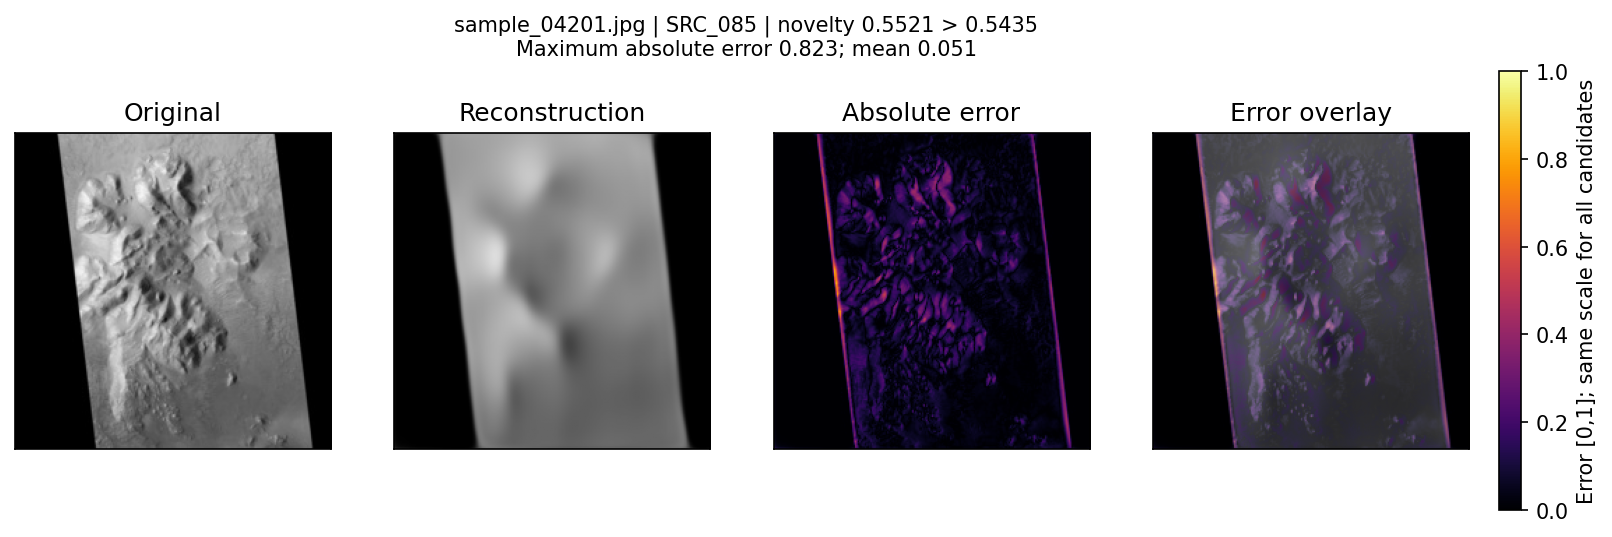

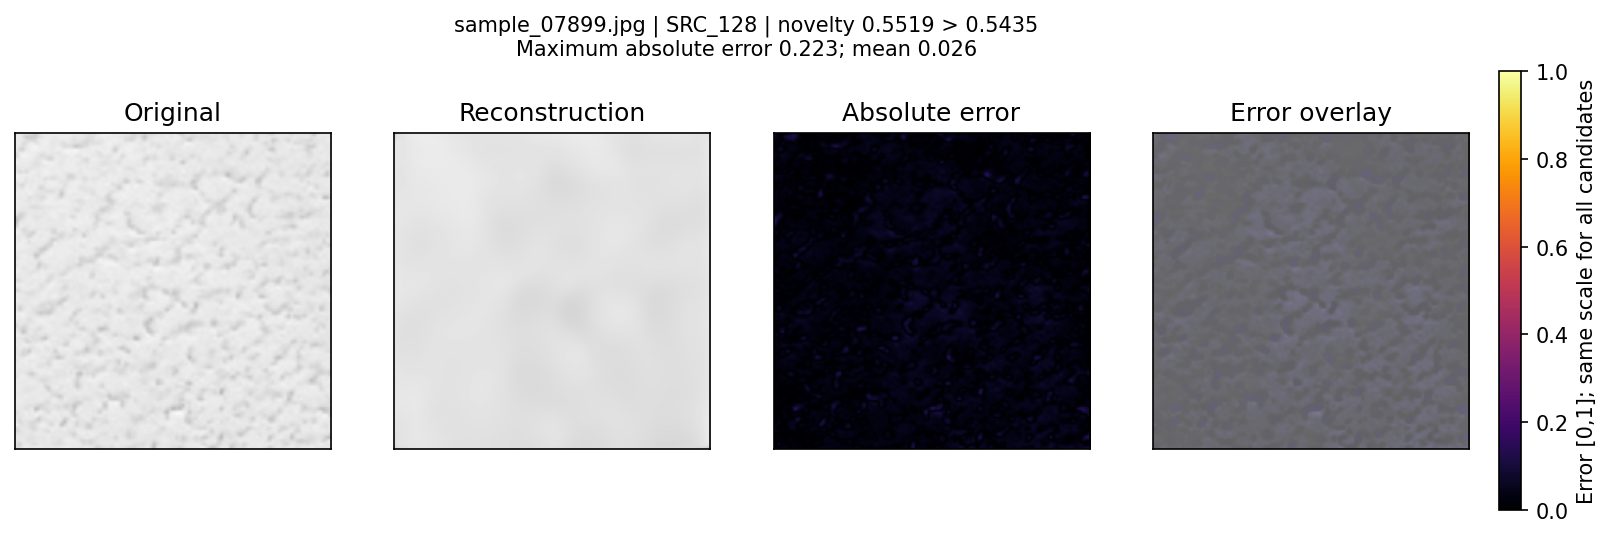

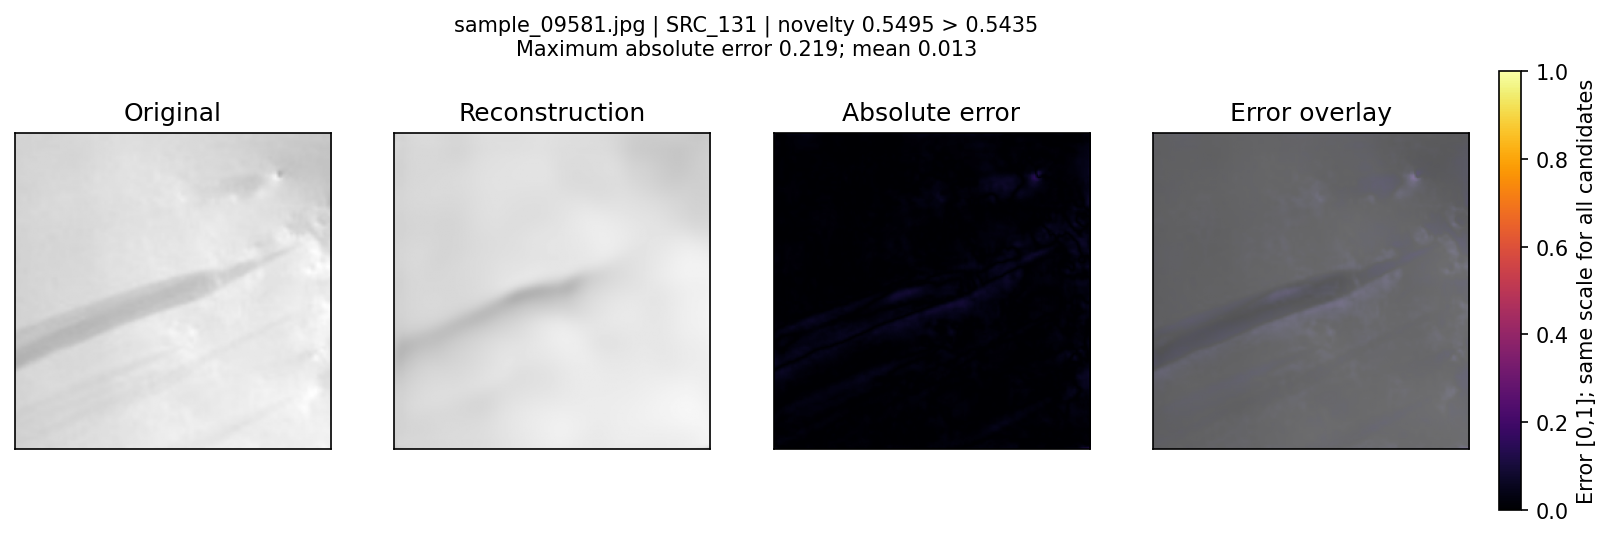

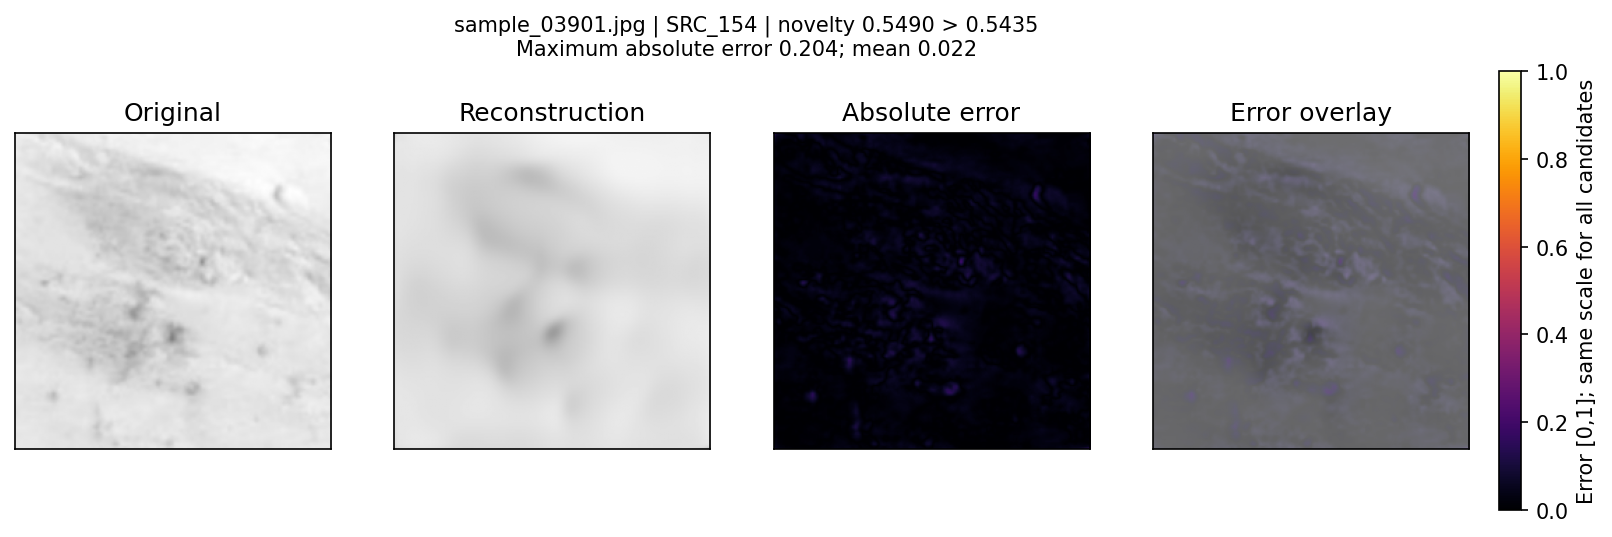

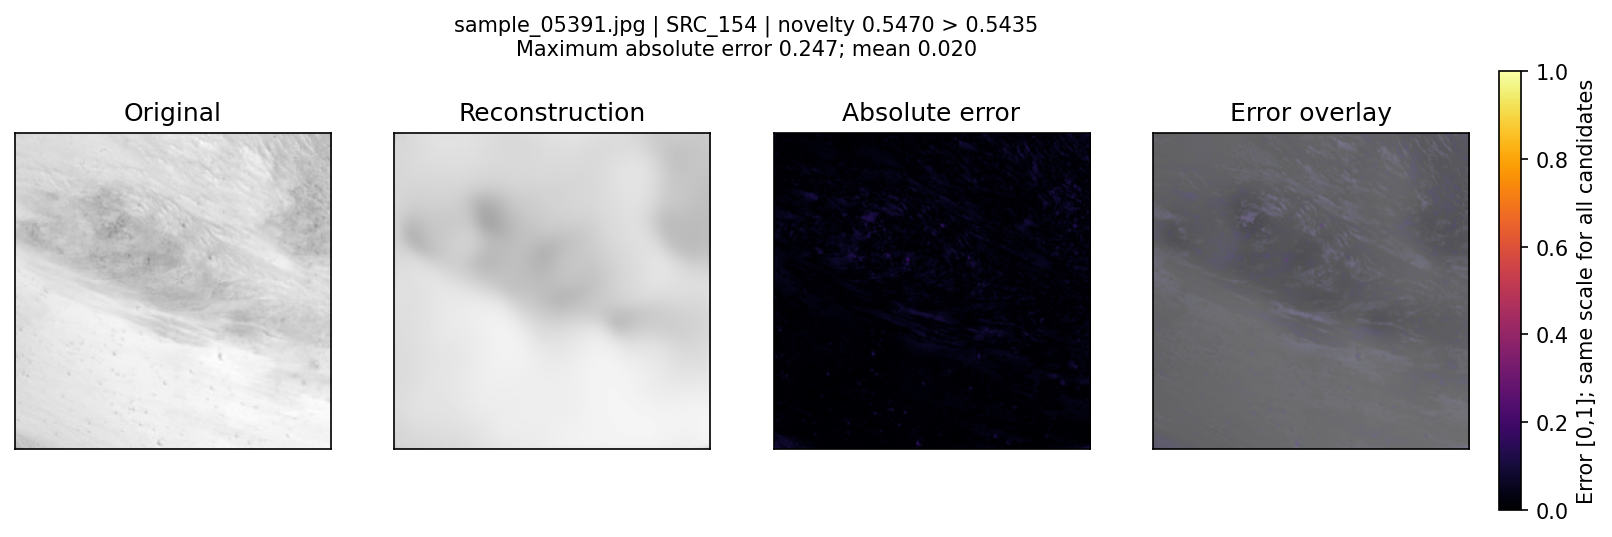

In [8]:
from IPython.display import display, HTML
out = ROOT/'outputs/v7/mixture_three_sigma_trees2000'
selected = pd.read_csv(out/'selected_for_interpretation.csv')
for _, row in selected.iterrows():
    fn = row['filename']
    display(HTML(f"<b>Candidate: {fn}</b> (Source: {row['source_image_id']}, Score: {row['novelty_score']:.5f})"))
    if (out/f"heatmap_{Path(fn).stem}.png").exists():
        display(Image(filename=str(out/f"heatmap_{Path(fn).stem}.png"), width=480))


## Phase 2.4 Secondary Metadata-Fusion Experiment (+2 Bonus)

We tested a secondary fusion pipeline using v8 augmented latents combined with normalized sun_angle, resolution, and one-hot season (excluding source IDs). We averaged scores from a 5-forest ensemble. We strictly evaluated this model by fitting a new GMM threshold solely on its calibration fused scores.


In [9]:
if (ROOT/'scripts/metadata_fusion.py').exists():
    subprocess.check_call([sys.executable, str(ROOT/'scripts/metadata_fusion.py')])
if (ROOT/'outputs/v8/fusion/calibration.json').exists():
    with open(ROOT/'outputs/v8/fusion/calibration.json') as f: calib = json.load(f)
    print("Fitted Fusion Threshold: T =", calib['threshold'])
if (ROOT/'outputs/v8/fusion/fused_novelty_scores.csv').exists():
    fusion_scores = pd.read_csv(ROOT/'outputs/v8/fusion/fused_novelty_scores.csv')
    flags = fusion_scores[fusion_scores['novelty_score'] > calib['threshold']]
    print(f"Total crops exceeding independently calibrated threshold: {len(flags)}")


Fitted Fusion Threshold: T = 0.554207333152199
Total crops exceeding independently calibrated threshold: 0
